# Exploratory Data Analysis (EDA)
## Maharashtra Crop Yield + Rainfall Dataset

In [2]:
!uv pip install pandas matplotlib scikit-learn seaborn

Resolved 18 packages in 17.05s
Prepared 9 packages in 1m 31s
         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.
Installed 12 packages in 1.30s
 + contourpy==1.3.3
 + cycler==0.12.1
 + fonttools==4.62.1
 + joblib==1.5.3
 + kiwisolver==1.5.0
 + matplotlib==3.10.9
 + pillow==12.2.0
 + pyparsing==3.3.2
 + scikit-learn==1.8.0
 + scipy==1.17.1
 + seaborn==0.13.2
 + threadpoolctl==3.6.0


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

In [4]:
df = pd.read_csv("./data/final_merged_data_rain_plus_crop_yield.csv")
print(f"Shape: {df.shape}")
print(f"\nYears: {df['Year'].min()} - {df['Year'].max()}")
print(f"Districts: {df['District'].nunique()}")
print(f"Crops: {df['Crop'].nunique()}")
df.head()

Shape: (19439, 23)

Years: 1998 - 2022
Districts: 34
Crops: 27


,District,Year,Crop,Season,Area,Production,Yield,Yield_Lag1,Yield_Lag2,Yield_3yr_Avg,...,june_percent_to_normal,july_normal_rainfall,july_actual_rainfall,july_percent_to_normal,august_normal_rainfall,august_actual_rainfall,august_percent_to_normal,september_normal_rainfall,september_actual_rainfall,september_percent_to_normal
0,ahilyanagar,1998,Arhar_Tur,Kharif,18800.0,9700.0,0.515957,0.357955,0.357955,0.515957,...,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3
1,ahilyanagar,1998,Bajra,Kharif,302400.0,243900.0,0.806548,0.557461,0.557461,0.806548,...,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3
2,ahilyanagar,1998,Castor_seed,Kharif,400.0,100.0,0.250000,0.250000,0.250000,0.250000,...,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3
3,ahilyanagar,1998,Cottonlint,Kharif,12100.0,19900.0,1.644628,1.644628,1.644628,1.644628,...,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3
4,ahilyanagar,1998,Gram,Rabi,59600.0,40900.0,0.686242,0.686242,0.686242,0.686242,...,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3


## 1. Data Overview

In [22]:
# Total yield per crop
crop_yield = df.groupby("Crop")["Yield"].sum().reset_index()

# Sort (optional, useful)
crop_yield = crop_yield.sort_values(by="Yield", ascending=False)

print(crop_yield)

                   Crop        Yield
8                 Maize  3209.090100
22            Sugarcane  1944.760322
5             Groundnut  1644.384482
17                 Rice  1567.219129
6                 Jowar  1232.025119
25                Wheat  1081.585946
3            Cottonlint  1041.853698
21             Soyabean   938.206853
19              Sesamum   890.696343
23            Sunflower   835.795156
4                  Gram   592.231529
0             Arhar_Tur   555.628387
24                 Urad   440.367946
20        Small_millets   421.537831
9       MoongGreen_Gram   400.757869
1                 Bajra   370.665525
15                 Ragi   319.436475
13    Other_Rabi_pulses   307.474946
11        Other_Cereals   298.363255
12  Other_Kharif_pulses   286.570967
18            Safflower   272.471273
16    Rapeseed_&Mustard   164.747444
2           Castor_seed   133.087740
26       other_oilseeds   126.999785
10           Niger_seed   125.317828
7               Linseed   120.291768
1

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19439 entries, 0 to 19438
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   District                     19439 non-null  str    
 1   Year                         19439 non-null  int64  
 2   Crop                         19439 non-null  str    
 3   Season                       19439 non-null  str    
 4   Area                         19439 non-null  float64
 5   Production                   19439 non-null  float64
 6   Yield                        19439 non-null  float64
 7   Yield_Lag1                   19439 non-null  float64
 8   Yield_Lag2                   19439 non-null  float64
 9   Yield_3yr_Avg                19439 non-null  float64
 10  Yield_3yr_Std                19439 non-null  float64
 11  june_normal_rainfall         19439 non-null  float64
 12  june_actual_rainfall         19439 non-null  float64
 13  june_percent_to_normal     

In [6]:
df.describe().round(4)

,Year,Area,Production,Yield,Yield_Lag1,Yield_Lag2,Yield_3yr_Avg,Yield_3yr_Std,june_normal_rainfall,june_actual_rainfall,june_percent_to_normal,july_normal_rainfall,july_actual_rainfall,july_percent_to_normal,august_normal_rainfall,august_actual_rainfall,august_percent_to_normal,september_normal_rainfall,september_actual_rainfall,september_percent_to_normal
count,19439.0000,19439.0000,1.943900e+04,19439.0000,19439.0000,19439.0000,19439.0000,19439.0000,19439.0000,19439.0000,19439.0000,19439.0000,19439.0000,19439.0000,19439.0000,19439.0000,19439.0000,19439.0000,19439.0000,19439.000
mean,2010.2304,25499.6220,3.132417e+04,0.9966,0.9829,0.9975,1.0045,0.2388,199.5594,201.2827,100.2175,314.6323,320.1877,102.7198,273.9961,258.3821,95.2333,175.6916,196.5548,111.600
std,7.4134,61546.5732,1.334702e+05,4.1176,4.5894,5.2410,4.2903,2.1939,155.8952,191.3567,48.7539,254.6756,296.7817,48.3870,173.3647,206.7650,44.3835,61.4532,129.2334,55.724
min,1998.0000,0.1000,0.000000e+00,0.0000,0.0000,0.0000,0.0000,0.0000,102.5000,0.0000,0.0000,94.8000,0.0000,0.0000,95.4000,0.0000,0.0000,109.5000,0.0000,0.000
25%,2004.0000,400.0000,2.000000e+02,0.3750,0.3724,0.3727,0.4073,0.0527,129.0000,97.0000,65.1000,166.4000,142.2000,69.0000,162.3000,129.5000,62.6000,146.7000,116.8000,70.400
50%,2010.0000,2700.0000,1.700000e+03,0.6463,0.6399,0.6311,0.6517,0.1366,155.4000,147.0000,94.5000,243.6000,239.5000,98.4000,227.8000,202.7000,89.0000,160.1000,171.0000,108.500
75%,2017.0000,20548.3250,1.620000e+04,1.1162,1.0920,1.0710,1.1226,0.2812,176.2000,222.2000,130.8000,308.9000,377.1000,132.2000,281.3000,302.1000,119.2000,183.6000,239.1000,146.100
max,2022.0000,765000.0000,9.030400e+06,275.0000,275.0000,275.0000,275.0000,158.6136,880.1000,1356.0000,269.3000,1206.2000,1874.3000,270.4000,874.5000,1318.0000,260.9000,412.1000,965.6000,313.400


## 2. Missing Value Analysis

In [7]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "No missing values!")
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values per column:
No missing values!

Total missing: 0


## 3. Target Variable — Yield Distribution

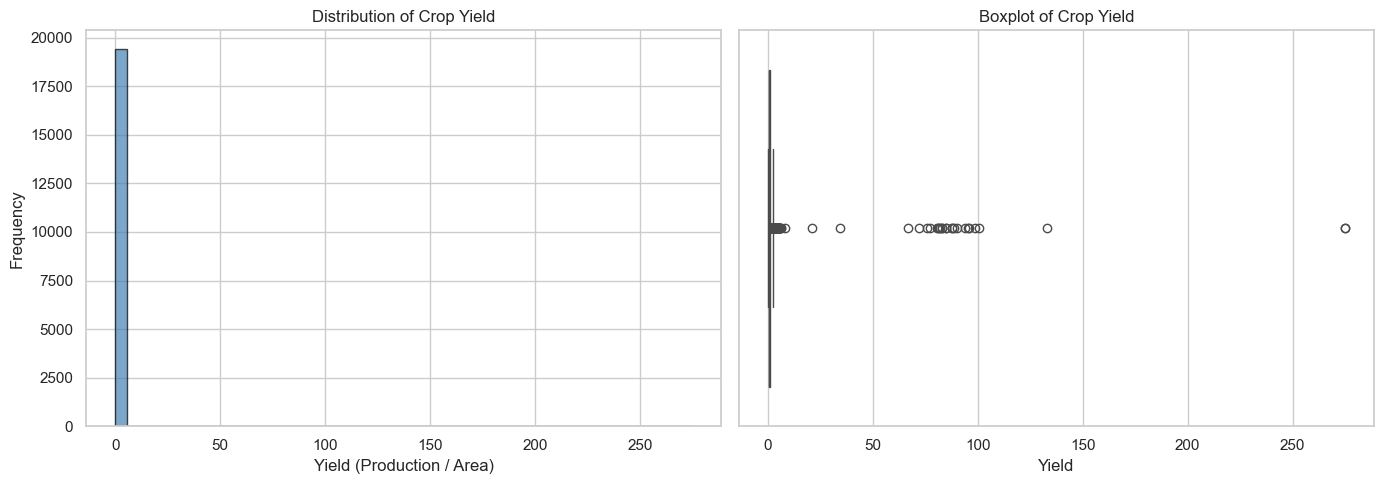

Range: 0.0000 to 275.0000
Mean: 0.9966, Median: 0.6463
Skewness: 41.5948


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Yield'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Distribution of Crop Yield')
axes[0].set_xlabel('Yield (Production / Area)')
axes[0].set_ylabel('Frequency')

sns.boxplot(x=df['Yield'], ax=axes[1], color='steelblue')
axes[1].set_title('Boxplot of Crop Yield')

plt.tight_layout()
plt.show()

print(f"Range: {df['Yield'].min():.4f} to {df['Yield'].max():.4f}")
print(f"Mean: {df['Yield'].mean():.4f}, Median: {df['Yield'].median():.4f}")
print(f"Skewness: {df['Yield'].skew():.4f}")

## 4. Yield Trends Over Time (1998–2022)

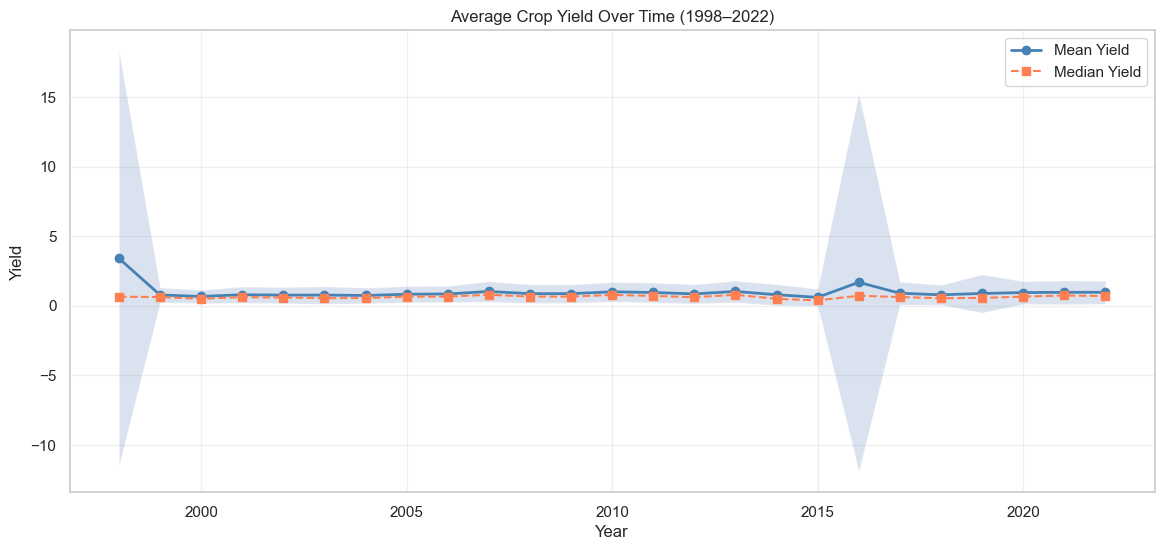

In [9]:
yearly = df.groupby('Year')['Yield'].agg(['mean','median','std']).reset_index()

plt.figure(figsize=(14, 6))
plt.plot(yearly['Year'], yearly['mean'], marker='o', label='Mean Yield', linewidth=2, color='steelblue')
plt.fill_between(yearly['Year'], yearly['mean']-yearly['std'], yearly['mean']+yearly['std'], alpha=0.2)
plt.plot(yearly['Year'], yearly['median'], marker='s', label='Median Yield', linewidth=1.5, linestyle='--', color='coral')
plt.title('Average Crop Yield Over Time (1998–2022)')
plt.xlabel('Year')
plt.ylabel('Yield')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Yield by District

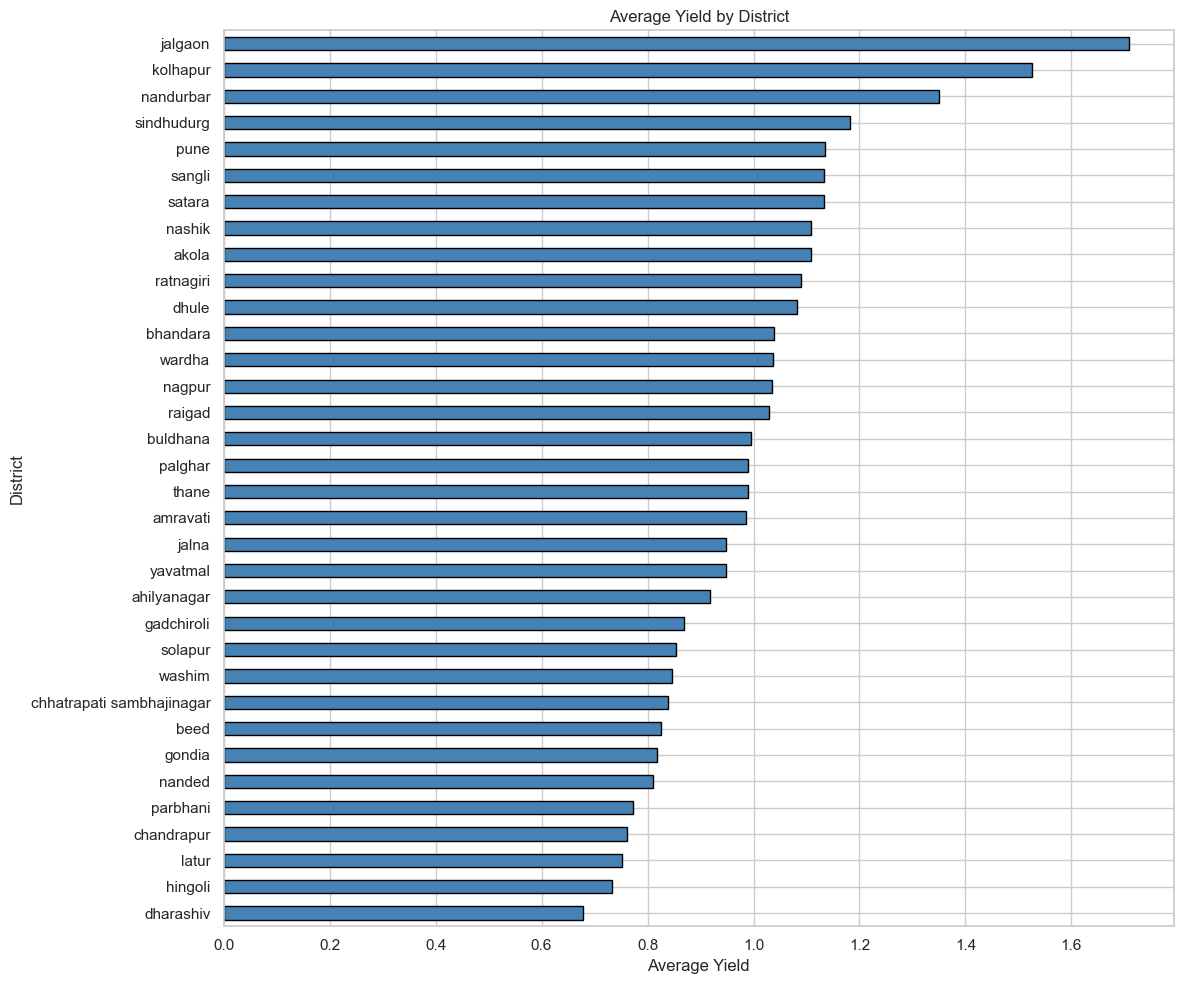

In [10]:
district_yield = df.groupby('District')['Yield'].mean().sort_values(ascending=True)

plt.figure(figsize=(12, 10))
district_yield.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Average Yield by District')
plt.xlabel('Average Yield')
plt.ylabel('District')
plt.tight_layout()
plt.show()

## 6. Yield by Crop

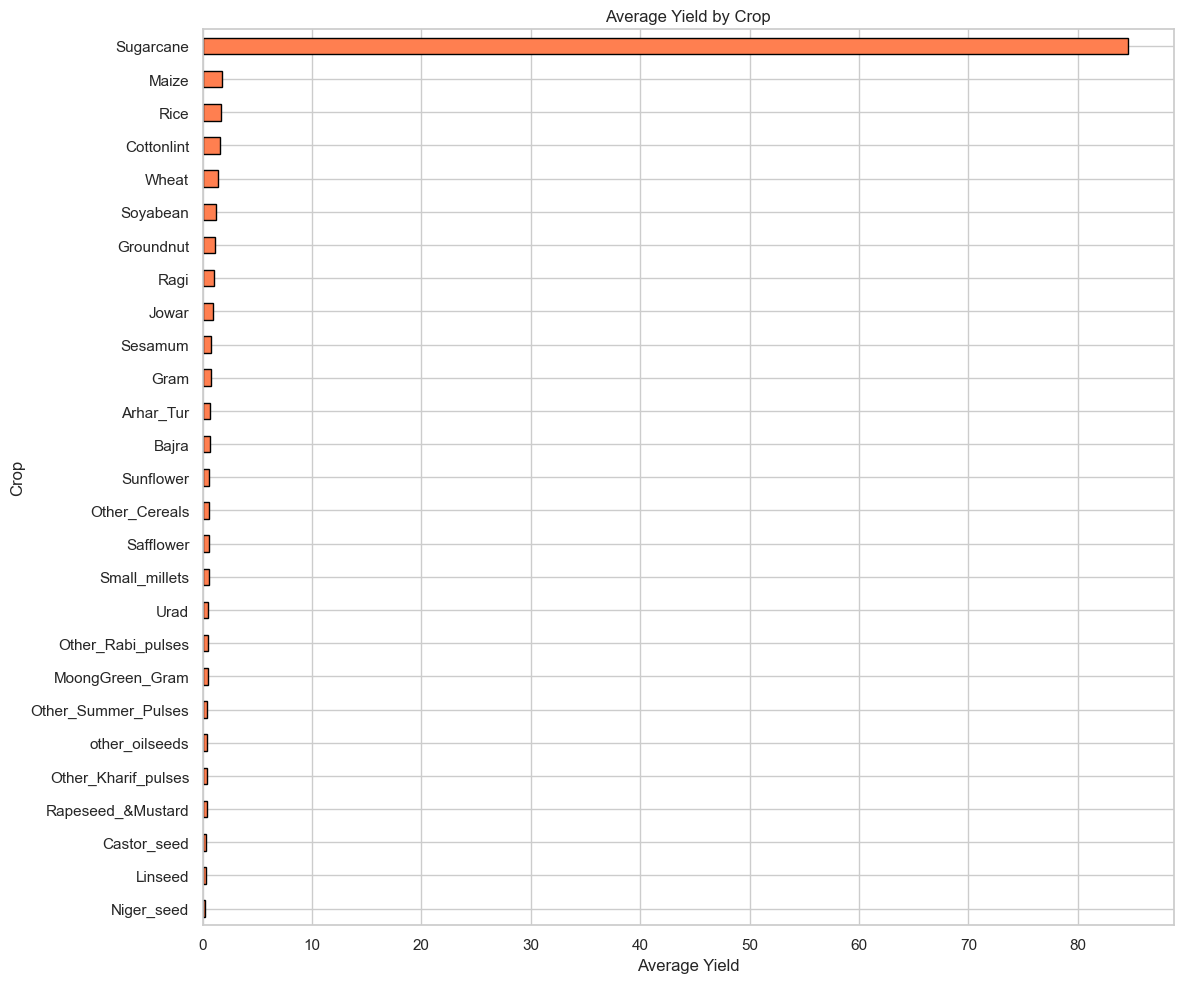

In [11]:
crop_yield = df.groupby('Crop')['Yield'].mean().sort_values(ascending=True)

plt.figure(figsize=(12, 10))
crop_yield.plot(kind='barh', color='coral', edgecolor='black')
plt.title('Average Yield by Crop')
plt.xlabel('Average Yield')
plt.ylabel('Crop')
plt.tight_layout()
plt.show()

## 7. Season Analysis

C:\Users\Anupam Kumar\AppData\Local\Temp\ipykernel_6552\3124967881.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Yield', ax=axes[1], palette='Set2')


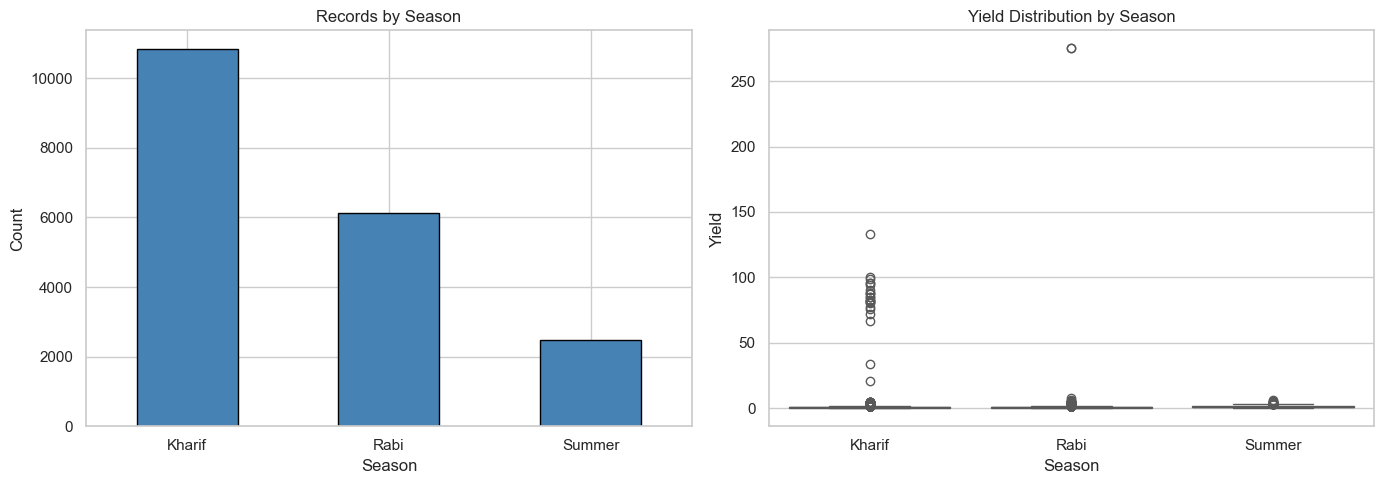

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Season'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Records by Season')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

sns.boxplot(data=df, x='Season', y='Yield', ax=axes[1], palette='Set2')
axes[1].set_title('Yield Distribution by Season')

plt.tight_layout()
plt.show()

## 8. Rainfall Trends Over Time

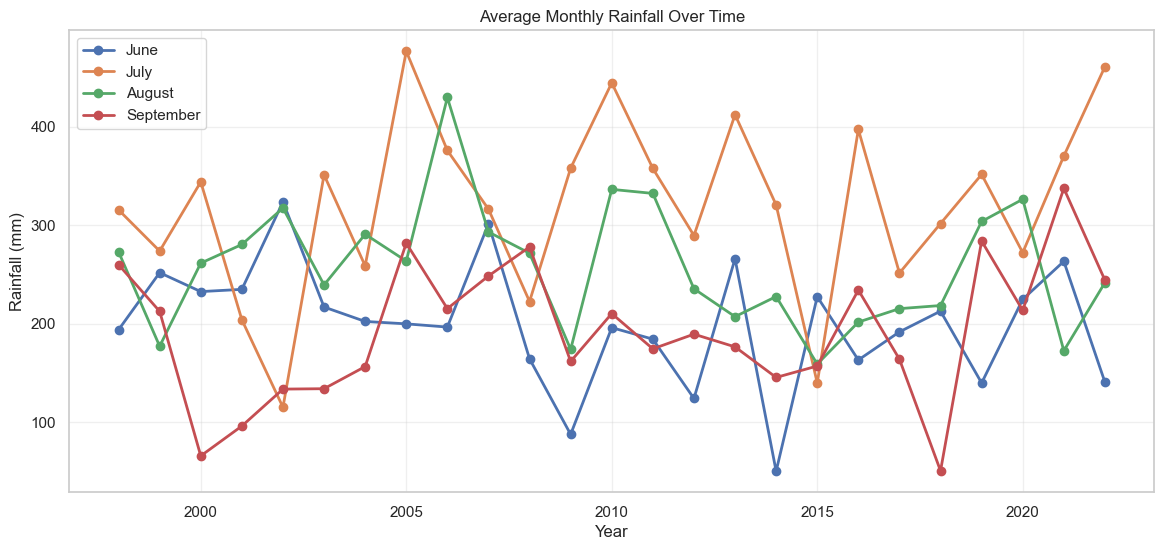

In [13]:
rainfall_cols = ['june_actual_rainfall','july_actual_rainfall','august_actual_rainfall','september_actual_rainfall']
yearly_rain = df.groupby('Year')[rainfall_cols].mean()

plt.figure(figsize=(14, 6))
for col in rainfall_cols:
    month = col.split('_')[0].capitalize()
    plt.plot(yearly_rain.index, yearly_rain[col], marker='o', label=month, linewidth=2)

plt.title('Average Monthly Rainfall Over Time')
plt.xlabel('Year')
plt.ylabel('Rainfall (mm)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 9. Rainfall Deviation from Normal

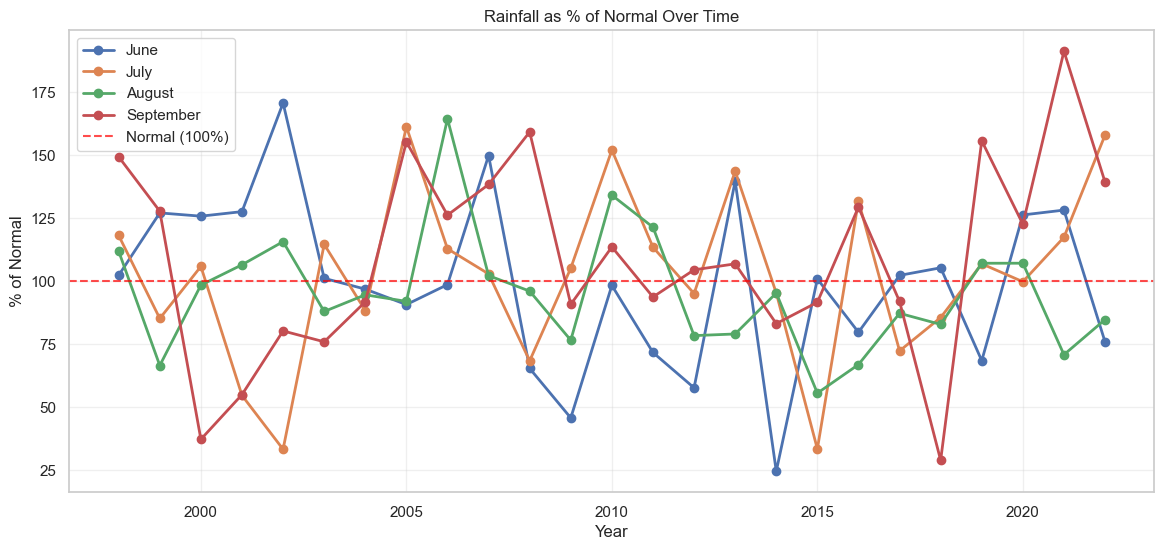

In [14]:
pct_cols = ['june_percent_to_normal','july_percent_to_normal','august_percent_to_normal','september_percent_to_normal']
yearly_pct = df.groupby('Year')[pct_cols].mean()

plt.figure(figsize=(14, 6))
for col in pct_cols:
    month = col.split('_')[0].capitalize()
    plt.plot(yearly_pct.index, yearly_pct[col], marker='o', label=month, linewidth=2)

plt.axhline(y=100, color='red', linestyle='--', alpha=0.7, label='Normal (100%)')
plt.title('Rainfall as % of Normal Over Time')
plt.xlabel('Year')
plt.ylabel('% of Normal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 10. Correlation Heatmap

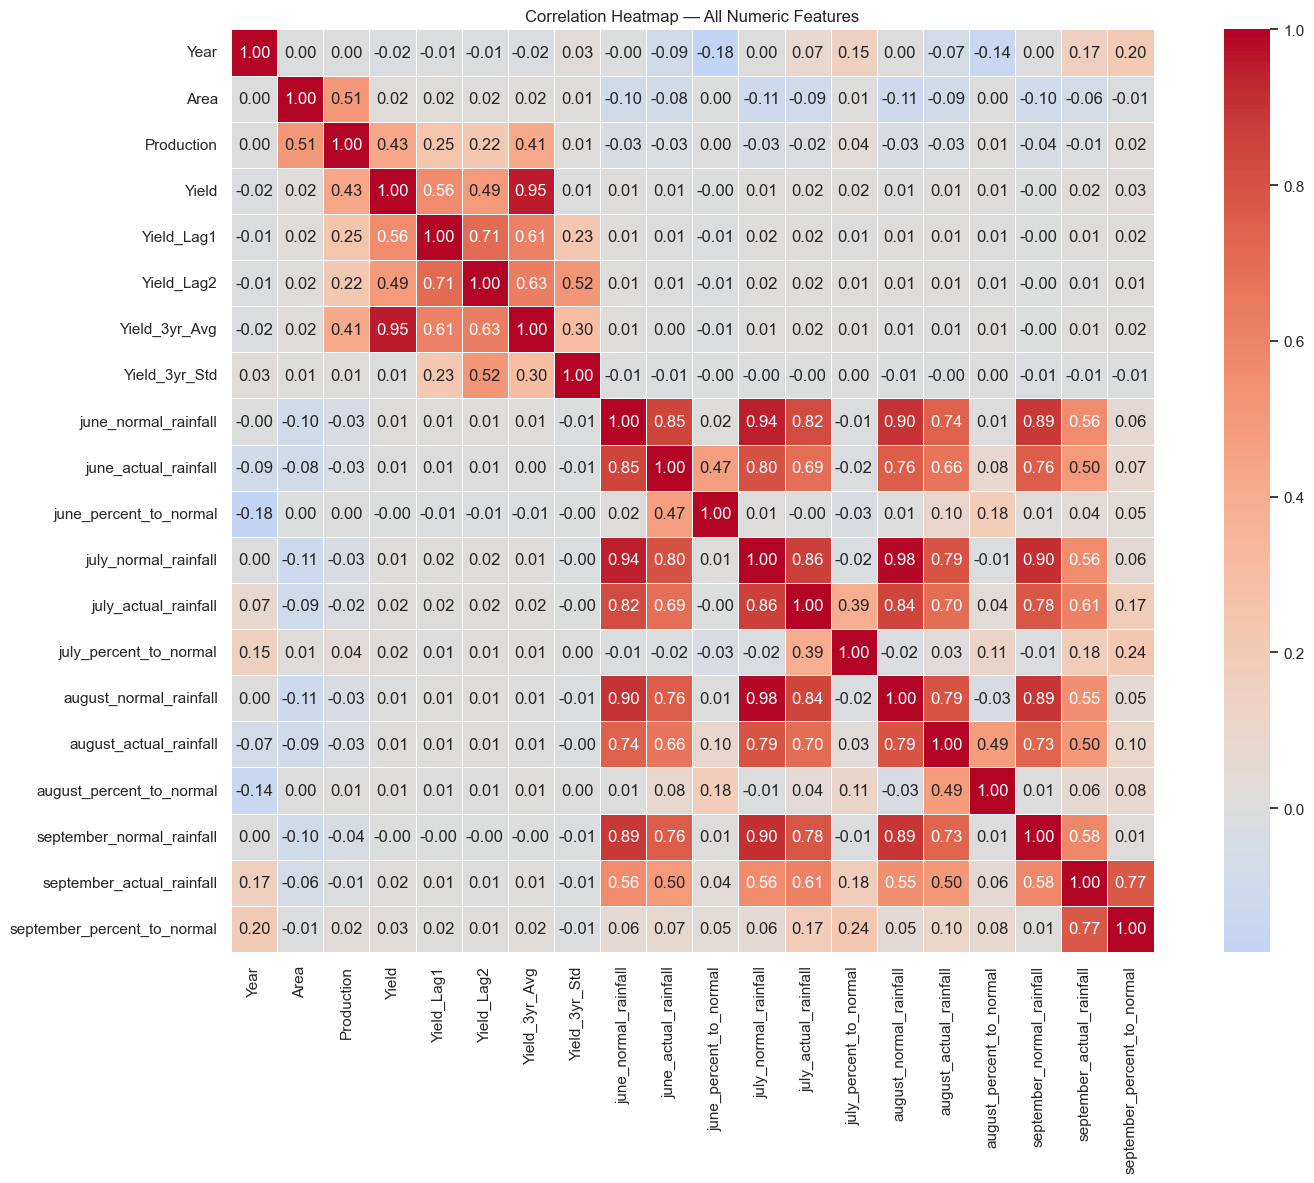

In [15]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap — All Numeric Features')
plt.tight_layout()
plt.show()

## 11. Rainfall vs Yield — Scatter Plots

In [32]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

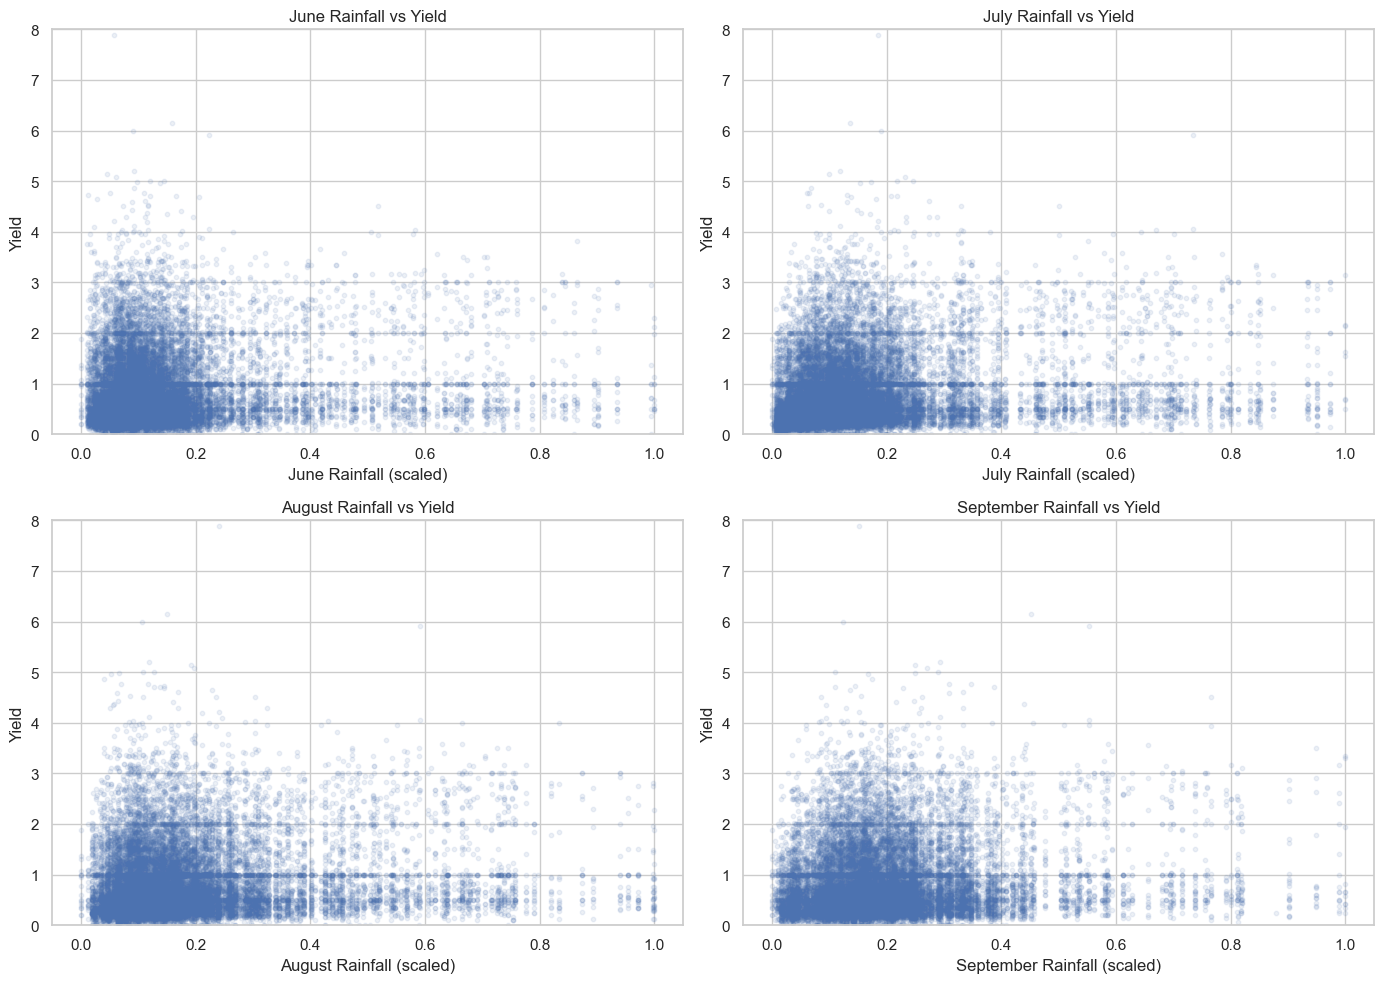

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

rainfall_cols = [
    'june_actual_rainfall',
    'july_actual_rainfall',
    'august_actual_rainfall',
    'september_actual_rainfall'
]

# Scale Yield ONCE
# df['Yield_norm'] = scaler.fit_transform(df[['Yield']])

for i, col in enumerate(rainfall_cols):
    ax = axes[i//2][i%2]
    month = col.split('_')[0].capitalize()
    
    # Scale rainfall column separately (without overwriting original)
    rainfall_scaled = scaler.fit_transform(df[[col]])
    
    ax.scatter(rainfall_scaled, df['Yield'], alpha=0.1, s=10)
    ax.set_ylim(0, 8)
    ax.set_ylabel('Yield')
    ax.set_xlabel(f'{month} Rainfall (scaled)')
    ax.set_title(f'{month} Rainfall vs Yield')

plt.tight_layout()
plt.show()

## 12. Drought vs Normal vs Excess Rain — Impact on Yield

In [39]:
Q1 = df['Yield'].quantile(0.25)
Q3 = df['Yield'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_filtered = df[(df['Yield'] >= lower) & (df['Yield'] <= upper)]

C:\Users\Anupam Kumar\AppData\Local\Temp\ipykernel_6552\2360253618.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=rainfall_cat, y=df_filtered['Yield'], palette='RdYlGn')


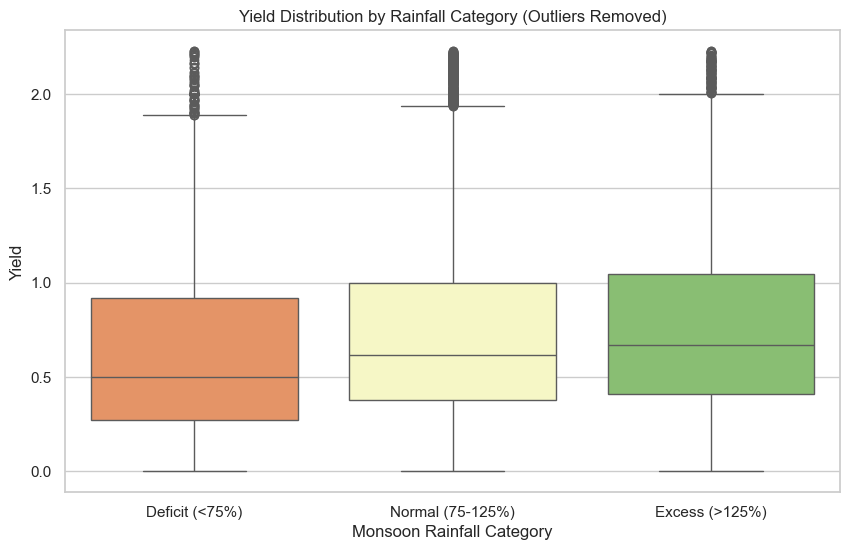

Mean yield by category:
Deficit (<75%)      0.628022
Normal (75-125%)    0.760603
Excess (>125%)      0.802052
Name: Yield, dtype: float64


In [40]:
avg_pct = df_filtered[pct_cols].mean(axis=1)

rainfall_cat = pd.cut(
    avg_pct,
    bins=[0, 75, 125, 999],
    labels=['Deficit (<75%)', 'Normal (75-125%)', 'Excess (>125%)']
)

plt.figure(figsize=(10, 6))
sns.boxplot(x=rainfall_cat, y=df_filtered['Yield'], palette='RdYlGn')

plt.title('Yield Distribution by Rainfall Category (Outliers Removed)')
plt.xlabel('Monsoon Rainfall Category')
plt.ylabel('Yield')

plt.show()

print("Mean yield by category:")
print(df_filtered.groupby(rainfall_cat)['Yield'].mean())

## 13. District × Crop Heatmap

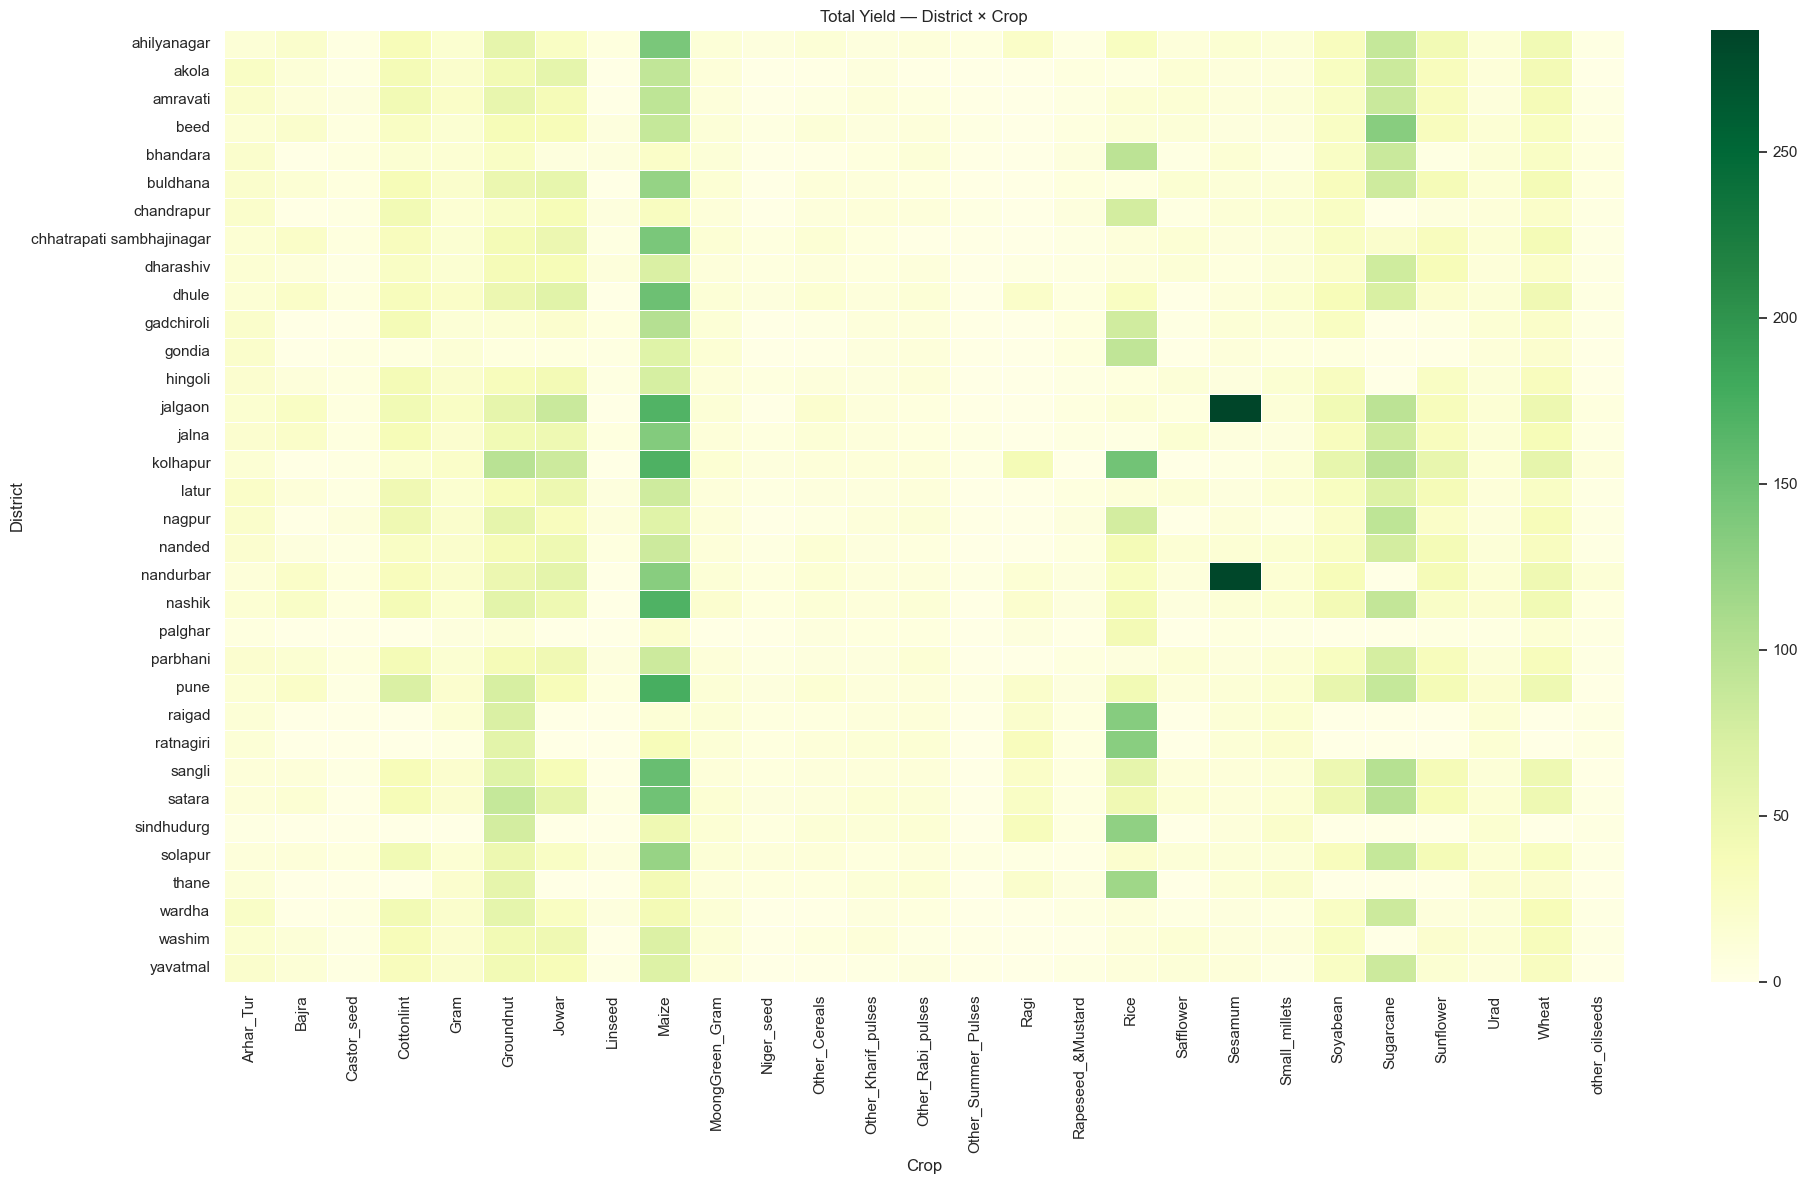

In [26]:
pivot = df.groupby(['District', 'Crop'])['Yield'].sum().unstack(fill_value=0)

plt.figure(figsize=(20, 12))
sns.heatmap(pivot, cmap='YlGn', linewidths=0.5)

plt.title('Total Yield — District × Crop')
plt.xlabel('Crop')
plt.ylabel('District')

plt.tight_layout()
plt.show()

## 14. Yield Stability — Mean vs Variability by Crop

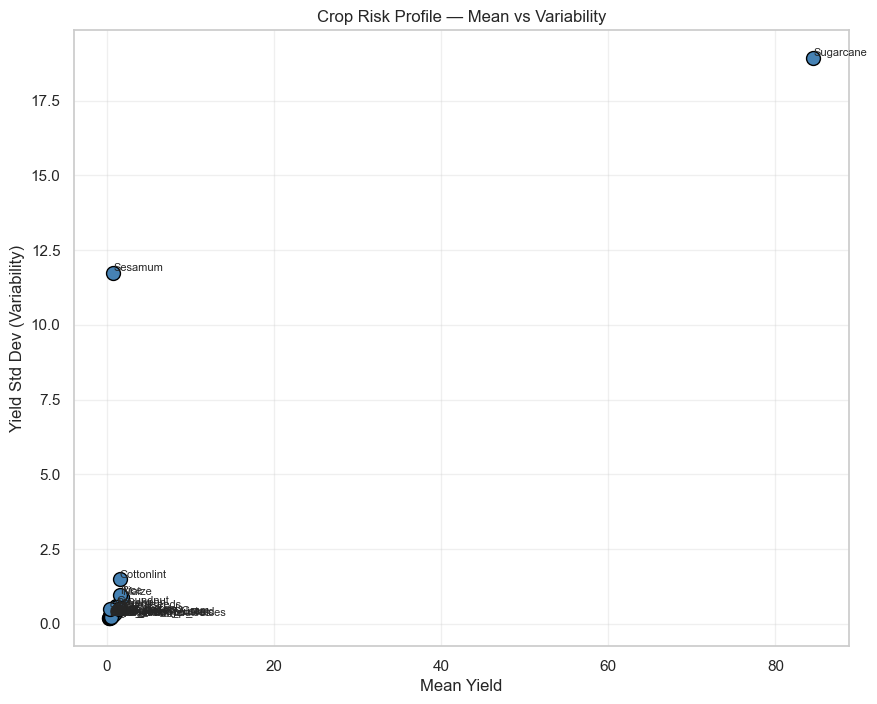

High yield + Low variability = BEST crops
Low yield + High variability = RISKY crops


In [19]:
crop_stats = df.groupby('Crop')['Yield'].agg(['mean','std']).reset_index()

plt.figure(figsize=(10, 8))
plt.scatter(crop_stats['mean'], crop_stats['std'], s=100, color='steelblue', edgecolors='black')

for _, row in crop_stats.iterrows():
    plt.annotate(row['Crop'], (row['mean'], row['std']), fontsize=8, ha='left', va='bottom')

plt.xlabel('Mean Yield')
plt.ylabel('Yield Std Dev (Variability)')
plt.title('Crop Risk Profile — Mean vs Variability')
plt.grid(True, alpha=0.3)
plt.show()
print("High yield + Low variability = BEST crops")
print("Low yield + High variability = RISKY crops")